# `Материалы кафедры ММП факультета ВМК МГУ. Введение в глубокое обучение.`

## `Задание 3.5. Трансформеры для Named Entity Recognition`

#### Фамилия, имя: Эчеверриа Арамбильет Антон

Дата выдачи: <span style="color:red">__10 апреля 23:00__</span>.

Мягкий дедлайн: <span style="color:red">__21 апреля 03:00__</span>.

Стоимость: __10 баллов__ (основная часть заданий)

<span style="color:red">__В ноутбуке все клетки должны выполняться без ошибок при последовательном их выполнении.__</span>

#### `Москва, 2026`

В рамках этого задания вы научитесь:
1. Загружать датасеты и претренированные модели из [Hugging face Hub](https://huggingface.co)
2. Манипулировать текстовыми датасетами с помощью библиотеки [datasets](https://huggingface.co/docs/datasets/index)
3. Запускать и обучать трансформеры с помощью библиотеки [transformers](https://huggingface.co/docs/transformers/index)
4. Промптить большую языковую модель на примере [Qwen3.5-4B](https://huggingface.co/Qwen/Qwen3.5-4B)
5. Оптимизировать гиперпараметры с помощью библиотеки [optuna](https://optuna.org/)

При выполнении задания вы будете решать стандартную задачу классификации токенов, в частности распознавание именованных сущностей.

Задание состоит из трёх частей:
1. Обработка данных и работа датасетами из Hugging Face.
2. Практика больших языковых моделей.
3. Дообучение трансформера.

Обратите свое вниманимание на [официальный гайд](https://huggingface.co/learn/nlp-course/chapter7/2), в котором подробно разбирается задача классификации токенов.

## `Часть 1. Загрузка и предобработка (4 балла)`

### `Подготовка среды Kaggle`

**Хранение ключей**: Kaggle Secrets --- инструмент для безопасного хранения и использования в ноутбуках Kaggle API-ключей, паролей или токенов.

Для добавления нового ключа:
1. Перейдите в Add-ons --> secrets
2. Add secret для добавления нового ключа. Доступ к ключу из ноутбука осуществляется с помощью пакета kaggle_secrets
3. Коллекция ключей общая для всех ноутбуков пользователя на kaggle. Но в каждом ноутбуке необходимо выбрать ключи, которые будут доступны через kaggle_secrets

Ниже находится пример подгрузки ключей для kaggle и wandb.

In [182]:
from kaggle_secrets import UserSecretsClient
import os

api_keys = UserSecretsClient()

os.system(f"huggingface-cli login --token {api_keys.get_secret('huggingface-cli')}")
os.system(f"wandb login {api_keys.get_secret('wandb')}")

sh: 1: huggingface-cli: not found
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


0

**Установка домашнего каталога**: Если мы хотим контролировать путь, по которому будут загружаться датасеты, чекпоинты моделей и т.д., то стоит задать переменную среды `HF_HOME`. При использовании kaggle перемещение домашнего каталога huggingface в директорию working позволит избежать повторной загрузки при перезапуске ноутбука (не забудьте установить "persistence: files only" в настройках kaggle-ноутбука)

In [2]:
# Optional

os.environ['HF_HOME'] = '/kaggle/working/hf_hub'

### `Подготовка среды Google Colab`

Секреты можно настроить в колабе:

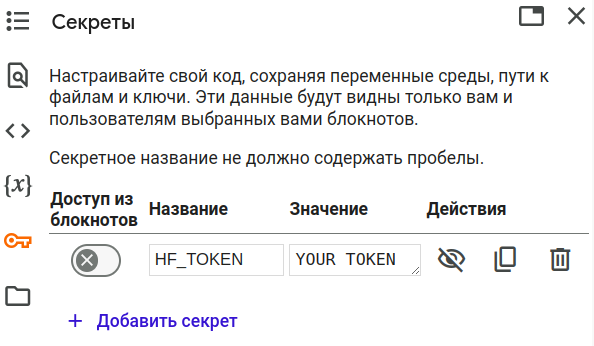

### `Установка зависимостей`

In [3]:
# pip offers the --quiet / -q option to silence output

! uv pip install -q "transformers[torch]==5.2.0" "outlines==1.2.12" datasets evaluate seqeval optuna

При работе с библиотеками часто бывает важно соблюдение версий. Задание тестировалось при версиях библиотек указанных ниже.

In [4]:
! uv pip freeze > requirements.txt
!cat requirements.txt | grep torch

Using Python 3.12.12 environment at: /usr
pytorch-ignite==0.5.3
pytorch-lightning==2.6.1
torch==2.10.0+cu128
torchao==0.10.0
torchaudio==2.10.0+cu128
torchcodec==0.10.0+cu128
torchdata==0.11.0
torchinfo==1.8.0
torchmetrics==1.9.0
torchsummary==1.5.1
torchtune==0.6.1
torchvision==0.25.0+cu128


In [5]:
!cat requirements.txt | grep transformers
!cat requirements.txt | grep datasets
!cat requirements.txt | grep evaluate
!cat requirements.txt | grep seqeval
!cat requirements.txt | grep optuna
!cat requirements.txt | grep outlines

sentence-transformers==5.2.3
transformers==5.2.0
datasets==4.8.3
tensorflow-datasets==4.9.9
vega-datasets==0.9.0
evaluate==0.4.6
seqeval==1.2.2
optuna==4.8.0
outlines==1.2.12
outlines-core==0.2.14


In [176]:
import gc
import json
import random
from typing import Any, Literal
from pathlib import Path

from abc import abstractmethod, ABC

import numpy as np
import numpy.typing as npt

import torch
import datasets
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    pipeline,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    AutoModelForCausalLM,
    PreTrainedModel, PreTrainedTokenizer,
)
from transformers.trainer_callback import EarlyStoppingCallback
from huggingface_hub import snapshot_download, login

import optuna
import evaluate
import outlines
from pydantic import BaseModel, Field, model_validator
from dataclasses import dataclass

torch.backends.cudnn.benchmark = True
torch.use_deterministic_algorithms(False)

torch.autograd.profiler.profile(False)
torch.autograd.profiler.emit_nvtx(False)
torch.autograd.set_detect_anomaly(False)

torch.set_float32_matmul_precision('high')
torch.backends.cuda.matmul.allow_tf32 = True

In [143]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def print_params_count(model):

    total_params = sum(p.numel() for p in model.parameters())
    total_params_grad = sum(p.numel() for p in model.parameters() if p.requires_grad)

    model_name = model.__class__.__name__
    print(f"Информация о числе параметров модели: {model_name}")
    print(f"Всего параметров: \t\t {total_params}")
    print(f"Всего обучаемых параметров: \t {total_params_grad}")
    print()

set_global_seed(42)

На протяжении всего задания вы можете добавлять любой `import`, иногда, это и являются частью задания. При работе с большими библиотеками очень важно уметь читать документацию и использовать гугл для поиска информации.

Для выполнения задания необходимо использование GPU!

In [8]:
if not torch.cuda.is_available():
    print("You need GPU!!!")

### `Загрузка данных (0.25 балла)`

В первую очередь, Hugging Face --- это хаб с датасетами и моделями. Загрузите готовый датасет [отсюда](https://huggingface.co/datasets/voorhs/conll2003-corrupted).

Подсказка: почитайте [туториал](https://huggingface.co/docs/datasets/load_hub).

*Если не получится сразу, то лучше перед следующими попытками перезапустить ноутбук.*

In [9]:
# YOUR CODE IS HERE
ds = datasets.load_dataset("voorhs/conll2003-corrupted")
ds

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.37M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/309k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/281k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

**Вопрос**: Какие поля нам доступны? Напечатайте пару примеров из каждого сплита. Попытайтесь догадаться какой смысл имеет каждое поле и опишите в двух словах.

*Подсказка:* почитайте [туториал](https://huggingface.co/docs/datasets/access).

In [18]:
for split_name in ["train", "validation", "test"]:
    print(split_name)
    for i in range(2):
        print(ds[split_name][i])
    print()

train
{'id': '473', 'tokens': ['LONDON', '1996-08-22'], 'pos_tags': [22, 11], 'chunk_tags': [11, 12], 'ner_tags': ['B-LOC', 'O']}
{'id': '8848', 'tokens': ['WorldCom', ',', 'which', 'said', 'it', 'will', 'buy', 'MFS', ',', 'shed', '1-3/4', 'to', 'close', 'at', '21', 'while', 'MFS', 'lost', '3-8/16', 'to', 'close', 'at', '41-5/16', '.'], 'pos_tags': [21, 6, 43, 38, 28, 20, 37, 22, 6, 38, 11, 35, 37, 15, 11, 15, 22, 38, 11, 35, 37, 15, 11, 7], 'chunk_tags': [11, 0, 11, 21, 11, 21, 22, 11, 0, 21, 11, 21, 22, 13, 11, 17, 11, 21, 22, 22, 22, 13, 3, 0], 'ner_tags': ['B-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O']}

validation
{'id': '0', 'tokens': ['CRICKET', '-', 'LEICESTERSHIRE', 'TAKE', 'OVER', 'AT', 'TOP', 'AFTER', 'INNINGS', 'VICTORY', '.'], 'pos_tags': [22, 8, 22, 22, 15, 22, 22, 22, 22, 21, 7], 'chunk_tags': [11, 0, 11, 12, 13, 11, 12, 12, 12, 12, 0], 'ner_tags': ['O', 'O', 'B-ORG', 'O', 'O', 'O', 'O',

**Ответ:** 
- id - просто порядковый номер
- tokens - список токенов соответвующего предложения
- pos_tags - грамм. структура предложения
- chunk_tags -  синтаксическая структура
- ner_tags - "что есть" данное слово (токен)

### `Удаление колонок (0.25 балла)`

Мы будем предсказывать NER tags непосредственно по тексту. Остальная информация нам не понадобится. Удалите все колонки кроме `tokens` и `ner_tags`.

*Подсказка:* почитайте [туториал](https://huggingface.co/docs/datasets/process#remove).

In [19]:
# YOUR CODE IS HERE
dataset_raw_essential = ds.select_columns(["tokens", "ner_tags"])
dataset_raw_essential

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 3453
    })
})

### `Сбор тегов (0.25 балла)`

Обратите внимание,что в датасете представлена **BIO-разметка**.

**BIO-разметка** -- это способ аннотации текста для распознавания именованных сущностей (NER), где **B** (Beginning) обозначает начало сущности, **I** (Inside) — продолжение той же сущности, а **O** (Outside) — отсутствие сущности.

Например, в предложении *"Apple выпустила новый iPhone"* разметка будет: *"Apple/B-ORG выпустила/O новый/O iPhone/B-PRODUCT"*.

В предложении  *"Билл Гейтс основал Microsoft"* -- *"Билл/B-PER Гейтс/I-PER основал/O Microsoft/B-ORG"*.

**Такой формат помогает моделям точно определять границы и типы сущностей.**



Прежде чем работать с датасетом, необходимо понять, какие именно NER-теги присутствуют в данных. Напечатайте все уникальные значения NER-тегов, которые встречаются в датасете.

*Подсказка:* по датасету можно итерироваться с помощью конструкции `for ... in`

**Вопрос:**
- есть ли какие-то подозрительные теги, которых быть не должно?

In [26]:
# YOUR CODE IS HERE
unique = set()
for split in ["train", "validation", "test"]:
    for example in dataset_raw_essential[split]:
        unique.update(example["ner_tags"])
print(unique)

{'B-ORG', 'O', 'B-PER', 'I-MISC', 'B-LOC', 'B-MISC', 'MISSING', 'I-ORG', 'I-LOC', 'I-PER'}


Тег MISSING не должен быть среди тегов (согласно документации CoNLL-2003)

Для вычисления лосс функции и подсчета метрик нам потребуется перевести теги в классы, так как мы будем решать задачу классификации.

Создайте мапинги тегов:
- `label2id`: строковое представление тега (например `B-PER`) -> индекс класса
- `id2label`: наоборот

Исключите из них подозрительные теги, которых не должно быть.

*Подсказка:* должно получиться 9 тегов

In [144]:
# YOUR CODE IS HERE
id2label = ["B-LOC", "B-MISC", "B-ORG", "B-PER", "I-LOC", "I-MISC", "I-ORG", "I-PER", "O"]

In [145]:
label2id = {name: i for i, name in enumerate(id2label)}
label2id

{'B-LOC': 0,
 'B-MISC': 1,
 'B-ORG': 2,
 'B-PER': 3,
 'I-LOC': 4,
 'I-MISC': 5,
 'I-ORG': 6,
 'I-PER': 7,
 'O': 8}

### `Фильтрация (0.25 балла)`

В обучающей выборке для части объектов пропущена разметка. Разделите обучающую выборку на размеченные и неразмеченные объекты. Напечатайте размеры обеих частей.

*Подсказка:* прочитайте [туториал](https://huggingface.co/docs/datasets/process#select-and-filter). Фильрацию датасета можно написать в одну строчку.

In [39]:
labeled = dataset_raw_essential["train"].filter(lambda x: any(tag != "MISSING" for tag in x["ner_tags"]))
unlabeled = dataset_raw_essential["train"].filter(lambda x: all(tag == "MISSING" for tag in x["ner_tags"]))
print(len(labeled))
print(len(unlabeled))
dataset_raw_essential["train"] = labeled
dataset_raw_essential["train_missing"] = unlabeled

10000
4041


In [40]:
assert len(dataset_raw_essential["train_missing"]) == 4041

### `Получение tokenizer-independent представления (2 балла)`

Имеющаяся BIO-разметка построена для токенизатора, который нам, к сожалению, **не известен**. Необходимо построить tokenizer-independent представление нашего датасета.

**Восстановление текста**: Для каждого объекта датасета необходимо объединить токены из `tokens` в единую строку и поместить в поле `text`. Необходимо учесть, что знаки препинания, кавычки и скобки (например, `,`, `.`, `!`. `)`, `"`) не должны иметь пробелов перед собой, но должны иметь пробел после себя.

**Изменение BIO-разметки**: Так как каждый токенизатор по-своему разобьет полученный `text`, то необходимо уметь строить BIO-разметку для любого токенизатора.

По имеющейся BIO-разметке необходимо:
* Оставить только последовательность сущностей, удалив префиксы начала (B- и I-).
* Для каждой именованной сущности найти позиции символов, ей соответствующие (в формате python slice).

Пример результата:
```python
{
    'text': '6 - Andre Agassi (U.S.) vs. Mauricio Hadad (Colombia)',
    'tags': ['PER', 'LOC', 'PER','LOC'],
    'ranges': [[4, 16], [19, 23], [30, 44], [47, 55]]
}
```

*Пояснение к примеру*. В тексте `'6 - Andre Agassi (U.S.) vs. Mauricio Hadad (Colombia)'` встретилось четыре сущности:
- `PER` на позициях `[4,16]`, а именно `Andre Agassi`
- `LOC` на позициях `[19,23]`, а именно `U.S.`
- `PER` на позициях `[30,44]`, а именно `Mauricio Hadad`
- `LOC` на позициях `[47,55]`, а именно `Colombia`

**Важно:**
- Полученный результат сохраните на диск (например по пути `./data/generic`)
- Подробности о названиях аргументов и возвращаемых значениях берите из докстринга функции `transform_ner_data`

In [45]:
def transform_ner_data(tokens: list[str], ner_tags: list[str]):
    """
    Obtain tokenizer-independent representation of a single sample.

    Args:
        tokens: list of words, subwords or even punctuations
        ner_tags: list of BIO labels
    Returns:
        sample: dictionary with the following contents:
            - text (str): detokenized sequence
            - tags (list[str]): list of tags names (PER, ORG, LOC, MISC)
            - ranges (list[tuple[int, int]]): list of python slices for each entity
    """

    punctuation_symbols = ("-", "'", ".", ",", ")", ":", ";", '"')

    text = ""
    ranges = []
    tags = []

    obj_start = None
    need_add_flag = False
    prev_token_end = 0

    for token, tag in zip(tokens, ner_tags):
        if len(text) > 0 and not token.startswith(
            punctuation_symbols
        ):
            text += " "

        token_start = len(text)
        text += token
        token_end = len(text)
        
        if tag.startswith("B-"):
            if obj_start is not None and need_add_flag:
                ranges.append((obj_start, prev_token_end))
                need_add_flag = False
            obj_start = token_start
            tags.append(tag[2:])
            need_add_flag = True
            
        elif tag.startswith("I-"):
            pass
            
        else:
            if obj_start is not None and need_add_flag:
                ranges.append((obj_start, prev_token_end))
                need_add_flag = False
        prev_token_end = token_end
    if obj_start is not None and need_add_flag:
        ranges.append((obj_start, prev_token_end))
        need_add_flag = False

    # Final output
    return {"text": text, "tags": tags, "ranges": ranges}

Проверьте, что все работает:

In [46]:
dataset_generic = dataset_raw_essential.map(
    function=transform_ner_data,
    input_columns=["tokens", "ner_tags"],
    remove_columns=dataset_raw_essential["train"].column_names,
    load_from_cache_file=False,
)

dataset_generic

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Map:   0%|          | 0/4041 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'tags', 'ranges'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text', 'tags', 'ranges'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['text', 'tags', 'ranges'],
        num_rows: 3453
    })
    train_missing: Dataset({
        features: ['text', 'tags', 'ranges'],
        num_rows: 4041
    })
})

In [49]:
dataset_generic["train"][:10]

{'text': ['LONDON 1996-08-22',
  'WorldCom, which said it will buy MFS, shed 1-3/4 to close at 21 while MFS lost 3-8/16 to close at 41-5/16.',
  '6- Andre Agassi ( U.S.) vs. Mauricio Hadad ( Colombia)',
  '" We\'ve always taken the view that we are the sort of company that\'s quite capable of working in difficult circumstances-- we\'re rather used to it.',
  'Extras ( lb-4 w-10 nb-7) 21',
  'He appeared to have been killed on Tuesday night, suffering at least eight stab wounds.',
  '9. Johan Capiot ( Belgium) Collstrop 32',
  "Honda's Takeda was pursued past Corser by the Yamaha duo of Noriyuki Haga and Wataru Yoshikawa with Haga briefly taking the lead in the final chicane on the last lap.",
  'Eager to put Lauck behind bars quickly and avoid a long and complex trial, prosecutor Bernd Mauruschat limited his charges to offences since 1994.',
  '1-0.'],
 'tags': [['LOC'],
  ['ORG', 'ORG', 'ORG'],
  ['PER', 'LOC', 'PER', 'LOC'],
  [],
  [],
  [],
  ['PER', 'LOC', 'ORG'],
  ['ORG', 'PER',

In [48]:
assert dataset_generic["train"][:10] == {
    'text': [
        'LONDON 1996-08-22',
        'WorldCom, which said it will buy MFS, shed 1-3/4 to close at 21 while MFS lost 3-8/16 to close at 41-5/16.',
        '6- Andre Agassi( U.S.) vs. Mauricio Hadad( Colombia)',
        '" We\'ve always taken the view that we are the sort of company that\'s quite capable of working in difficult circumstances-- we\'re rather used to it.',
        'Extras( lb-4 w-10 nb-7) 21', 'He appeared to have been killed on Tuesday night, suffering at least eight stab wounds.',
        '9. Johan Capiot( Belgium) Collstrop 32',
        "Honda's Takeda was pursued past Corser by the Yamaha duo of Noriyuki Haga and Wataru Yoshikawa with Haga briefly taking the lead in the final chicane on the last lap.",
        'Eager to put Lauck behind bars quickly and avoid a long and complex trial, prosecutor Bernd Mauruschat limited his charges to offences since 1994.', '1-0.'
    ],
    'tags': [
        ['LOC'],
        ['ORG', 'ORG', 'ORG'],
        ['PER', 'LOC', 'PER', 'LOC'],
        [],
        [],
        [],
        ['PER', 'LOC', 'ORG'],
        ['ORG', 'PER', 'PER', 'ORG', 'PER', 'PER', 'PER'],
        ['PER', 'PER'],
        []
    ], 'ranges': [
        [[0, 6]],
        [[0, 8], [33, 36], [70, 73]],
        [[3, 15], [17, 21], [27, 41], [43, 51]],
        [],
        [],
        [],
        [[3, 15], [17, 24], [26, 35]],
        [[0, 5], [8, 14], [32, 38], [46, 52], [60, 73], [78, 94], [100, 104]],
        [[13, 18], [86, 102]],
        []
    ]
}

AssertionError: 

Сохраните результат на диск:

In [50]:
# YOUR CODE IS HERE
dataset_generic.save_to_disk("./data/generic")

Saving the dataset (0/1 shards):   0%|          | 0/10000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3250 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3453 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4041 [00:00<?, ? examples/s]

### `Токенизация (1 балл)`

Для отладки воспользуемся токенизатором модели `google-bert/bert-base-uncased`.

In [51]:
bert_tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [52]:
print(bert_tokenizer(dataset_generic["train"]["text"][11]))

{'input_ids': [101, 3078, 3707, 6434, 2001, 27502, 1010, 6352, 11000, 1010, 2403, 1012, 1019, 3867, 2062, 2084, 2197, 2251, 1998, 1014, 1012, 1015, 3867, 2062, 2084, 1999, 2238, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


У каждого токенизатора есть свои специальные токены, для получения этой информации можно воспользоваться соотвествующей переменной.

In [53]:
bert_tokenizer.all_special_ids

[100, 102, 0, 101, 103]

Теперь надо написать функцию, которая по имеющуемуся tokenizer-independent представлению выдает BIO-разметку для предоставленного токенизатора.  Реализуйте функцию `align_tokens_and_tags`, которая трансформирует один объект из датасета. Все подробности о формате входных данных берите из докстринга.

**Важно:** служебные токены, добавляемые токенизатором должны иметь специальный лейбл `SPECIAL_TOKENS_LABEL`, т.к. их не надо учитывать при сборе лосса.

In [54]:
SPECIAL_TOKENS_LABEL = -100


def align_tokens_and_tags(
    text: str, tags: list[str], ranges: list[tuple[int, int]], tokenizer: AutoTokenizer
):
    """
    Align the tokenizer-independent representation with a Hugging Face tokenizer.

    Args:
        text: original text.
        tags: list of entity tags (e.g., ["PER", "LOC"]).
        ranges: list of (start, end) character ranges for each entity.
        tokenizer: A Hugging Face tokenizer.

    Returns:
        dict: A dictionary with `input_ids`, `labels`:
            - input_ids are tokens indices in tokenizer's vocabulary
            - labels are integer labels for BIO tags (from label2id mapping)

    Note:
        This function
    """
    encoding = tokenizer(
        text, return_offsets_mapping=True, truncation=True, padding=False
    )
    tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"])
    token_ids = encoding["input_ids"]
    offset_mapping = encoding["offset_mapping"]

    # Initialize BIO tags for each token
    ner_tags = ["O"] * len(tokens)

    # YOUR CODE IS HERE
    for i, (token_start, token_end) in enumerate(offset_mapping):
        if token_start == token_end:
            continue
        
        for (range_start, range_end), tag in zip(ranges, tags):
            if token_start >= range_start and token_end <= range_end:
                if token_start == range_start:
                    ner_tags[i] = "B-" + tag
                else:
                    ner_tags[i] = "I-" + tag
                break
    return {
        "input_ids": token_ids,
        "labels": [
            SPECIAL_TOKENS_LABEL if token_id in tokenizer.all_special_ids else label2id[lab]
            for lab, token_id in zip(ner_tags, token_ids, strict=True)
        ],
    }

In [55]:
def tokenize_ner_dataset(
    dataset: datasets.DatasetDict | datasets.Dataset, tokenizer: AutoTokenizer
):
    return dataset.map(
        function=align_tokens_and_tags,
        input_columns=["text", "tags", "ranges"],
        fn_kwargs={"tokenizer": tokenizer},
        remove_columns=(
            dataset["train"] if "train" in dataset else dataset
        ).column_names,
    )

Вот пара примеров того, что должно получиться:

In [56]:
for i in range(9, 12):
    sample = dataset_generic["train"][i]
    print("before tokenization:", sample)
    tokenized_sample = align_tokens_and_tags(**sample, tokenizer=bert_tokenizer)
    print("after tokenization:", tokenized_sample)
    print()

before tokenization: {'text': '1-0.', 'tags': [], 'ranges': []}
after tokenization: {'input_ids': [101, 1015, 1011, 1014, 1012, 102], 'labels': [-100, 1, 1, 1, 1, -100]}

before tokenization: {'text': 'Puchon 3 Chonan 0 ( halftime 1-0)', 'tags': ['ORG', 'ORG'], 'ranges': [[0, 6], [9, 15]]}
after tokenization: {'input_ids': [101, 16405, 24561, 1017, 16480, 7229, 1014, 1006, 22589, 1015, 1011, 1014, 1007, 102], 'labels': [-100, 0, 6, 1, 0, 6, 1, 1, 1, 1, 1, 1, 1, -100]}

before tokenization: {'text': 'Primary iron output was 297,700 tonnes, 14.5 percent more than last July and 0.1 percent more than in June.', 'tags': [], 'ranges': []}
after tokenization: {'input_ids': [101, 3078, 3707, 6434, 2001, 27502, 1010, 6352, 11000, 1010, 2403, 1012, 1019, 3867, 2062, 2084, 2197, 2251, 1998, 1014, 1012, 1015, 3867, 2062, 2084, 1999, 2238, 1012, 102], 'labels': [-100, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -100]}



Тесты:

In [62]:
dataset_tokenized = tokenize_ner_dataset(dataset_generic, bert_tokenizer)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Map:   0%|          | 0/4041 [00:00<?, ? examples/s]

In [63]:
dataset_tokenized["train"][5:7]

{'input_ids': [[101,
   2002,
   2596,
   2000,
   2031,
   2042,
   2730,
   2006,
   9857,
   2305,
   1010,
   6114,
   2012,
   2560,
   2809,
   17079,
   8710,
   1012,
   102],
  [101,
   1023,
   1012,
   13093,
   6178,
   25185,
   1006,
   5706,
   1007,
   8902,
   4877,
   13181,
   2361,
   3590,
   102]],
 'labels': [[-100, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, -100],
  [-100, 8, 8, 3, 7, 7, 8, 0, 8, 2, 6, 6, 6, 8, -100]]}

In [64]:
assert dataset_tokenized["train"][5:7] == {
    "input_ids": [
        [
            101,
            2002,
            2596,
            2000,
            2031,
            2042,
            2730,
            2006,
            9857,
            2305,
            1010,
            6114,
            2012,
            2560,
            2809,
            17079,
            8710,
            1012,
            102,
        ],
        [
            101,
            1023,
            1012,
            13093,
            6178,
            25185,
            1006,
            5706,
            1007,
            8902,
            4877,
            13181,
            2361,
            3590,
            102,
        ],
    ],
    "labels": [
        [-100, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, -100],
        [-100, 8, 8, 3, 7, 7, 8, 0, 8, 2, 6, 6, 6, 8, -100],
    ],
}

## `Часть 2. Доразметка с помощью LLM (2 балла)`

Наконец, обратимся к трансфомерам! Причем сразу к большим.

Мы воспользуемся моделью `Qwen3.5` на 4 миллиарда параметров.

In [65]:
class Mention(BaseModel):
    entity: str = Field(description="String literal from the original text referring to some entity.")
    tag: Literal["PER", "LOC", "ORG", "MISC"] = Field(description="Specific NER tag.")

class NERLabeling(BaseModel):
    reasoning: str = Field(description="Short preliminary speculations on the answer. 100-200 tokens max")
    text: str = Field(description="Original text to find entities within.")
    mentions: list[Mention] = Field(description="The entities found within the text.")

    @model_validator(mode="after")
    def validate_entities(self):
        for mention in self.mentions:
            if mention.entity not in self.text:
                raise ValueError(
                    f"Invalid mention: {mention}. No corresponding "
                    "substring found in the original text."
                )
        return self

In [66]:
class Generator(ABC):

    @abstractmethod
    def generate_plain(self, query: str) -> str: ...

    def generate(self, query: str) -> NERLabeling:
        response = self.generate_plain(query)
        start_dict = response.find("{")
        end_dict = response.rfind("}")
        return NERLabeling.model_validate_json(response[start_dict : end_dict + 1])

### `Промт инжиниринг`

Для удобства парсинга, мы будем просить LLM возвращать ответы сразу в формате `json` словаря.

Напишите промт, в котором перечислите и опишите поля словаря, которые вы хотите получать от LLM.

**Важно:** скорее всего, вы будете возвращаться к этому заданию и редактировать промт, чтобы улучшить качество дальшейших шагов.

In [67]:
def messages_maker(text: str) -> list[dict[str, str]]:
    """
    Creates a prompt for the LLM inference to generate NER labels.

    Args:
        text: The input text to be labeled.
    Returns:
        list: A list of messages formatted for the LLM inferemce.
    """
    system_message = (
        "You are an expert in Named Entity Recognition (NER). Your task is to analyze the given text and identify "
        "entities such as persons (PER), locations (LOC), organizations (ORG), and miscellaneous (MISC). "
        "You must return the results in a specific JSON format with the following fields: "
        "The 'reasoning' field should contain all your initial thoughts for solving NER task. "
        ##############
        # YOUR PROMPT
        ##############
        "The 'text' field should contain the original input text exactly as given with no changes. "
        "The 'mentions' field should be a list of objects, each with: "
        "'entity' which must be the exact string from the original text referring to the entity, "
        "'tag' which must be one of the following substrings: 'PER', 'LOC', 'ORG', 'MISC'. "
        "If there are no entities in the text, return an empty list for 'mentions'. "
        "Return only the JSON object, no additional text, that's critical."
    )

    user_message = f"Please analyze the following text and generate the NER labels as described:\n\n{text}"

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_message},
    ]

    return messages

Для обработки одного примера будем использовать функцию `generate_answer`.

**Важно:** чтобы понимать, как это работает, почитайте [туториал](https://huggingface.co/docs/transformers/main/en/conversations#textgenerationpipeline).

In [68]:
class JSONGenerator(Generator):
    def __init__(self, model_name: str) -> None:
        self.generator = pipeline(model=model_name, task="text-generation", device="cuda")

    def generate_plain(self, query: str) -> str:
        chat = self.generator(messages_maker(query), max_new_tokens=1024)[0]["generated_text"]
        return chat[-1]["content"]


Эта функция отправляет текстовый запрос `query` большой языковой модели и возвращает ответ:

In [69]:
model_name = "Qwen/Qwen3.5-4B"

In [70]:
# Download the model without loading it into RAM/VRAM
snapshot_download(repo_id=model_name)

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

'/kaggle/working/hf_hub/hub/models--Qwen--Qwen3.5-4B/snapshots/851bf6e806efd8d0a36b00ddf55e13ccb7b8cd0a'

In [71]:
generator = JSONGenerator(model_name)

print(type(generator.generator))

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

<class 'transformers.pipelines.text_generation.TextGenerationPipeline'>


In [72]:
print_params_count(generator.generator.model)

Информация о числе параметров модели: Qwen3_5ForCausalLM
Всего параметров: 		 4205751296
Всего обучаемых параметров: 	 4205751296



In [73]:
print(generator.generate_plain("I live in London, but my father is from Germany."))

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Thinking Process:

1.  **Analyze the Request:**
    *   Task: Named Entity Recognition (NER).
    *   Input Text: "I live in London, but my father is from Germany."
    *   Output Format: JSON object.
    *   JSON Fields: `reasoning` (string), `text` (string, original input), `mentions` (list of objects with `entity` and `tag`).
    *   Tags: 'PER', 'LOC', 'ORG', 'MISC'.
    *   Constraint: Return *only* the JSON object, no additional text.

2.  **Analyze the Input Text:**
    *   Sentence: "I live in London, but my father is from Germany."
    *   Potential Entities:
        *   "I": Pronoun, not an entity.
        *   "live": Verb, not an entity.
        *   "in": Preposition, not an entity.
        *   "London": City name. This is a Location (LOC).
        *   "but": Conjunction, not an entity.
        *   "my": Possessive pronoun, not an entity.
        *   "father": Common noun, refers to a person but not a specific named entity (unless context implies a specific title, but genera

In [74]:
print(generator.generate_plain("Can't wait the Oasis reunion."))

Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Thinking Process:

1.  **Analyze the Request:**
    *   Task: Named Entity Recognition (NER).
    *   Input Text: "Can't wait the Oasis reunion."
    *   Output Format: JSON object with specific fields:'reasoning', 'text','mentions'.
    *   Entity Tags: 'PER' (Person), 'LOC' (Location), 'ORG' (Organization), 'MISC' (Miscellaneous).
    *   Constraint: Return *only* the JSON object, no additional text.

2.  **Analyze the Input Text:** "Can't wait the Oasis reunion."
    *   "Can't": Contraction of "Can not". Not an entity.
    *   "wait": Verb. Not an entity.
    *   "the": Article. Not an entity.
    *   "Oasis": This refers to the British rock band Oasis. It is a proper noun referring to an organization/group. Tag: 'ORG'.
    *   "reunion": Common noun. Not an entity.
    *   ".": Punctuation. Not an entity.

3.  **Identify Entities:**
    *   Entity: "Oasis"
    *   Type: 'ORG' (Organization/Group).

4.  **Draft Reasoning:**
    *   Scan the text for proper nouns.
    *   "Oasis" is

In [75]:
print(generator.generate_plain("Check, please."))

Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Thinking Process:

1.  **Analyze the Request:**
    *   Task: Named Entity Recognition (NER).
    *   Input Text: "Check, please."
    *   Output Format: JSON object with specific fields ('reasoning', 'text','mentions').
    *   Entity Tags: 'PER' (Person), 'LOC' (Location), 'ORG' (Organization), 'MISC' (Miscellaneous).
    *   Constraint: Return *only* the JSON object, no additional text.

2.  **Analyze the Input Text:**
    *   Text: "Check, please."
    *   Meaning: This is a polite instruction or request for verification. It contains no proper nouns, names, locations, organizations, or specific miscellaneous entities typically classified in NER tasks (like dates, times, amounts, quantities, etc., though the prompt specifies PER, LOC, ORG, MISC).
    *   Potential Entities:
        *   "Check": A verb or noun. Not a specific entity.
        *   "please": An interjection/adverb. Not a specific entity.
    *   Conclusion: No named entities (PER, LOC, ORG, MISC) are present.

3.  **Dra

In [76]:
print(generator.generate_plain("Сигма сигма боой сигма боой сигма бой."))

Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Thinking Process:

1.  **Analyze the Request:**
    *   Task: Named Entity Recognition (NER).
    *   Input Text: "Сигма сигма боой сигма боой сигма бой." (Russian text).
    *   Output Format: JSON object with fields'reasoning', 'text','mentions'.
    *   Entity Tags: 'PER' (Person), 'LOC' (Location), 'ORG' (Organization), 'MISC' (Miscellaneous).
    *   Constraint: Return *only* the JSON object, no additional text.

2.  **Analyze the Input Text:**
    *   Text: "Сигма сигма боой сигма боой сигма бой."
    *   Language: Russian.
    *   Content: It looks like nonsense, gibberish, or a specific pattern where "Сигма" (Sigma) and "боой/бой" are repeated.
    *   Literal Translation/Meaning: "Sigma sigma booy sigma booy sigma boy."
    *   Potential Entities:
        *   "Сигма" (Sigma): Could be an acronym, a name, a chemical symbol, or just a word. In a general NER context without specific context, it's often treated as a common noun or potentially an organization/person name if specifi

### `Отключить ризонинг (0.25 балла)`

Вы могли заметить, что генерация ризонинга внутри `<think></think>` занимает много времени. Отключите ее.

*Помощь:*
- https://huggingface.co/docs/transformers/chat_templating
- https://huggingface.co/Qwen/Qwen3.5-4B/blob/main/chat_template.jinja
- https://huggingface.co/docs/transformers/v5.4.0/en/internal/tokenization_utils#transformers.PreTrainedTokenizerBase.apply_chat_template.*kwargs
- https://github.com/huggingface/transformers/blob/9a9997fd73c5eb29fb3677d3c489f5d3cd0765f6/src/transformers/tokenization_utils_base.py#L3026

In [93]:
del generator
gc.collect()
torch.cuda.empty_cache()

In [97]:
class NoReasoningGenerator(Generator):
    def __init__(self, model_name="Qwen/Qwen3.5-4B"):
        self.generator = pipeline(
            model=model_name,
            task="text-generation",
            device="cuda",
        )

    def generate_plain(self, query: str):
        messages = messages_maker(query)
        prompt = self.generator.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False,
        )
        output = self.generator(
            prompt,
            max_new_tokens=1024,
            return_full_text=False,
        )
        return output[0]["generated_text"]

In [98]:
generator = NoReasoningGenerator()

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

In [99]:
print(generator.generate_plain("I live in London, but my father is from Germany."))

Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{
  "reasoning": "The text contains two location entities. 'London' is a city, tagged as LOC. 'Germany' is a country, tagged as LOC. There are no persons, organizations, or other miscellaneous entities mentioned.",
  "text": "I live in London, but my father is from Germany.",
  "mentions": [
    {
      "entity": "London",
      "tag": "LOC"
    },
    {
      "entity": "Germany",
      "tag": "LOC"
    }
  ]
}



In [100]:
print(generator.generate_plain("Can't wait the Oasis reunion."))

Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{
  "reasoning": "The text 'Can't wait the Oasis reunion.' contains one entity: 'Oasis'. 'Oasis' is a well-known British pop group, which classifies it as an Organization (ORG). The words 'Can't', 'wait', 'the', and'reunion.' are not entities. Therefore, only 'Oasis' will be tagged as ORG.",
  "text": "Can't wait the Oasis reunion.",
  "mentions": [
    {
      "entity": "Oasis",
      "tag": "ORG"
    }
  ]
}



In [101]:
print(generator.generate_plain("Check, please."))

Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{
  "reasoning": "The input text 'Check, please.' consists of imperative verbs and a polite particle. There are no named persons (PER), locations (LOC), organizations (ORG), or specific miscellaneous entities (MISC) identified. Therefore, the mentions list will be empty.",
  "text": "Check, please.",
  "mentions": []
}



In [103]:
print(generator.generate_plain("Сигма сигма боой сигма боой сигма бой."))

Both `max_new_tokens` (=1024) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{
  "reasoning": "The input text 'Сигма сигма боой сигма боой сигма бой' consists entirely of the word 'сигма' (sigma) repeated with variations of 'боой/бой' (likely noise or misspellings of 'boy'). There are no recognized persons, locations, organizations, or standard miscellaneous entities defined in the task scope. Therefore, no entities are extracted.",
  "text": "Сигма сигма боой сигма боой сигма бой.",
  "mentions": []
}



In [124]:
del generator
gc.collect()
torch.cuda.empty_cache()

NameError: name 'generator' is not defined

### `Структурированный выход (1 балл)`

Ответы LLM не всегда точны. Часто она галлюцинирует или просто делает не то, о чем ее попросили. Поэтому для удобной автоматизации работы с LLM важно уметь валидировать ответы.

1. Проанализируйте ответы LLM из предыдущих ячеек с вызовом `generate_answer` и предположите какие ошибки может делать LLM при генерации ответа.

2. Реализуйте умную fancy валидацию с помощью библиотеки `outlines`

**Вопросы:**
- Какие ошибки LLM можно простить?
- Приведите примеры ошибок (и валидных семплов) и продемонстрируйте работу вашего валидатора

**Важно:** скорее всего, вы будете возвращаться к этому заданию и редактировать промт, чтобы улучшить качество дальшейших шагов.

*Замечание:* скорее всего вам понадобится явно указать такие параметры: `max_new_tokens=512, do_sample=False` (подробнее, почему так: [issue](https://github.com/dottxt-ai/outlines/issues/1392))

In [137]:
torch.cuda.empty_cache()

In [141]:
# У меня память заполнялась до отказа, приходилось полностью чистить GPU, а потом заново вызывать библиотеки и основые функции / классы для корректной работы
import gc
for name in list(globals()):
    obj = globals()[name]
    if hasattr(obj, 'parameters') or hasattr(obj, 'model') or hasattr(obj, 'generator'):
        if name not in ('AutoModelForCausalLM', 'AutoTokenizer'):
            print(f"Deleting {name}")
            del globals()[name]

gc.collect()
torch.cuda.empty_cache()
print(f"Free GPU memory: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GiB")

Deleting PreTrainedModel
Deleting outlines
Deleting generator
Free GPU memory: 14.41 GiB


In [146]:
class StructuredGenerator(Generator):
    def __init__(self, model_name="Qwen/Qwen3.5-4B"):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = outlines.from_transformers(
            AutoModelForCausalLM.from_pretrained(model_name, dtype=torch.float16, device_map="cuda"),
            self.tokenizer
        )

    def generate_plain(self, query):
        messages = messages_maker(query)
        prompt = self.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False,
        )
        return self.model(prompt, NERLabeling, max_new_tokens=512)

In [147]:
generator = StructuredGenerator()

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

In [148]:
print(generator.generate("I live in London, but my father is from Germany.").__repr__())

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


NERLabeling(reasoning="The text contains two location entities: 'London' and 'Germany'. 'London' is a city, which is a location (LOC). 'Germany' is a country, which is also a location (LOC). There are no persons (PER) or organizations (ORG) mentioned. The pronoun 'my' and 'father' are not entities in this context as they refer to the speaker and a family member but are not specific named entities. 'I' is a pronoun, not a named entity. So, the entities are 'London' (LOC) and 'Germany' (LOC).", text='I live in London, but my father is from Germany.', mentions=[Mention(entity='London', tag='LOC'), Mention(entity='Germany', tag='LOC')])


In [149]:
print(generator.generate("Can't wait the Oasis reunion.").__repr__())

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


NERLabeling(reasoning="The text 'Can't wait the Oasis reunion.' contains the entity 'Oasis', which is a well-known music band/organization. It should be tagged as ORG. 'reunion' is a common noun and not an entity. 'Can't wait' is an expression. No persons, locations, or other miscellaneous entities are present.", text="Can't wait the Oasis reunion.", mentions=[Mention(entity='Oasis', tag='ORG')])


In [150]:
print(generator.generate("Check, please.").__repr__())

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


NERLabeling(reasoning="The text 'Check, please.' is a common polite phrase used to request attention or verification. There are no specific persons (PER), locations (LOC), organizations (OR), or miscellaneous entities (MISC) explicitly named or identifiable in this short sentence. It is a general imperative sentence without proper nouns or specific referents.", text='Check, please.', mentions=[])


In [151]:
print(generator.generate("Сигма сигма боой сигма боой сигма бой.").__repr__())

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


NERLabeling(reasoning="The input text 'Сигма сигма боой сигма боой сигма бой' consists of repeated words that appear to be nonsensical or misspelled variations of 'Sigma' (Сигма) and 'Boy' (бой/боой). There are no recognizable persons, locations, organizations, or standard miscellaneous entities (like dates, numbers, or specific proper nouns) in this text. The words do not form coherent entities.", text='Сигма сигма боой сигма боой сигма бой.', mentions=[])


### `Обработка ответа LLM (0.75 балла)`

Напишите функцию `generate_ner_labeling`, которая для данного примера
- обращается к LLM чтобы получить разметку (с помощью функции `generate_answer`, определенной ранее)
- парсит ответ LLM в питоновский словарь (с помощью функции `parse`, см. ниже)
- валидирует словарь (с помощью функции `validate`, определенной ранее)
- делает `k_tries` попыток, пока LLM не выдаст валидный ответ

**Важно:** для простоты считайте что в одном тексте одна и та же сущность не повторяется (т.е. "i work at apple and eat an apple" нет в датасете).

*Подсказка:*
- пользуйтесь конструкцией `try except`

Уделите особое внимание следующему вопросу:
- как лучше всего получать `ranges`: просить LLM или пытаться сделать самому?

In [152]:
@dataclass
class LabelWithRanges:
    label: NERLabeling
    ranges: list[tuple[int, int]]

In [153]:
def generate_ner_labeling(
    text: str, generator: Generator, k_tries: int = 3
) -> LabelWithRanges:
    """
    Generates NER labeling for the given text using the provided LLM instance.

    Args:
        text: The input text to label.
        llm: The LLM instance for generating NER labels.
        k_tries: Maximum number of attempts to generate valid JSON.

    Returns:
        A dictionary containing 'text', 'tags', 'ranges', 'reasoning' if managed to generate valid samples,
            otherwise dict with 'tags', 'ranges', 'reasoning' are filled with None.
    """
    # YOUR CODE IS HERE
    for attempt in range(k_tries):
        try:
            label = generator.generate(text)
            # по-хорошему, в generate реализовано обращение, парсинг и валидация (через интегрированный NERLabeling)
            ranges = []
            for mention in label.mentions:
                start = text.find(mention.entity)
                if start == -1:
                    raise ValueError(f"Entity '{mention.entity}' not found")
                end = start + len(mention.entity)
                ranges.append((start, end))

            return LabelWithRanges(label=label, ranges=ranges)

        except Exception as e:
            print(f"{e}. Retrying... {attempt} attempt")
    print(f"Failed to generate valid NER labeling after {k_tries} attempts.")
    return {"text": text, "tags": None, "ranges": None, "reasoning": None}

Хороший результат должен выглядеть подобным образом:

In [154]:
generate_ner_labeling("I live in London but my dog Jack doesn't like it.", generator)

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


LabelWithRanges(label=NERLabeling(reasoning="The text contains two potential entities. 'London' is a well-known city, which falls under the location category (LOC). 'Jack' is the name of a dog, which is a person's name but in this context refers to an animal/personification, so it could be considered a person (PER) or miscellaneous (MISC). However, since it's a proper name used as a noun, it's often tagged as PER in NER tasks unless specified otherwise. Let's stick with PER for 'Jack' as it's a proper name. 'I' is a pronoun, not an entity. 'my' is a possessive pronoun. 'doesn't', 'like', 'it' are not entities. So the entities are 'London' (LOC) and 'Jack' (PER).", text="I live in London but my dog Jack doesn't like it.", mentions=[Mention(entity='London', tag='LOC'), Mention(entity='Jack', tag='PER')]), ranges=[(10, 16), (28, 32)])

Загрузите из памяти ранее загруженный датасет в tokenizer-independent представлении.

In [155]:
# YOUR CODE IS HERE
dataset_generic = datasets.load_from_disk("./data/generic")

Мы не можем полноценно разметить 4000+ примеров. Работа LLM на потребительском железе и особенно в облачных средах типа Google Colab и Kaggle очень медленная.

В качестве щадящего режима авторы задания предлагают сделать следующее: доразметить только 10 примеров в пределах от 15 до 30 символов.

In [156]:
subset_size = 10
min_chars = 15
max_chars = 30
# YOUR CODE IS HERE
dataset = dataset_generic["train_missing"].filter(lambda x: min_chars <= len(x["text"]) <= max_chars).select(range(subset_size))

Filter:   0%|          | 0/4041 [00:00<?, ? examples/s]

Приступим к синтезированию!

In [157]:
synthetic = [generate_ner_labeling(sample["text"], generator) for sample in dataset]

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


1 validation error for NERLabeling
  Value error, Invalid mention: entity='Slovakia' tag='LOC'. No corresponding substring found in the original text. [type=value_error, input_value={'reasoning': "The text '...ovakia', 'tag': 'LOC'}]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error. Retrying... 0 attempt


Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


1 validation error for NERLabeling
  Value error, Invalid mention: entity='Slovakia' tag='LOC'. No corresponding substring found in the original text. [type=value_error, input_value={'reasoning': "The text '...ovakia', 'tag': 'LOC'}]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error. Retrying... 1 attempt


Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


1 validation error for NERLabeling
  Value error, Invalid mention: entity='Slovakia' tag='LOC'. No corresponding substring found in the original text. [type=value_error, input_value={'reasoning': "The text '...ovakia', 'tag': 'LOC'}]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error. Retrying... 2 attempt
Failed to generate valid NER labeling after 3 attempts.


Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Хороший результат должен быть примерно таким:

In [159]:
synthetic

[LabelWithRanges(label=NERLabeling(reasoning="The text 'Salim Malik not out 6' contains a name 'Salim Malik' which is a person (PER). 'not out' is a cricket status (MISC). '6' is a score (MISC).", text='Salim Malik not out 6', mentions=[Mention(entity='Salim Malik', tag='PER'), Mention(entity='not out', tag='MISC'), Mention(entity='6', tag='MISC')]), ranges=[(0, 11), (12, 19), (20, 21)]),
 {'text': '21. Slovakia 8.15',
  'tags': None,
  'ranges': None,
  'reasoning': None},
 LabelWithRanges(label=NERLabeling(reasoning="The input text is 'WASHINGTON 1996-08-23'. 'WASHINGTON' is a well-known city and state in the United States, so it is a location (LOC). '1996-08-23' is a date, which falls under miscellaneous (MISC) as it is not a person, location, or organization. No other entities are present.", text='WASHINGTON 1996-08-23', mentions=[Mention(entity='WASHINGTON', tag='LOC'), Mention(entity='1996-08-23', tag='MISC')]), ranges=[(0, 10), (11, 21)]),
 LabelWithRanges(label=NERLabeling(reas

Результат присоедините к трейновой части нашего `generic` датасета и сохраните результат в папке `generic-synthetic`.

**Важно:** не забудьте отфильтровать неудачные результаты генерации, если они есть (это про случаи когда `k_tries` исчерпались)

In [218]:
# YOUR CODE IS HERE
good_synthetic = [s for s in synthetic if isinstance(s, LabelWithRanges)]

synthetic_records = {
    "text": [s.label.text for s in good_synthetic],
    "tags": [[m.tag for m in s.label.mentions] for s in good_synthetic],
    "ranges": [s.ranges for s in good_synthetic],
}
synthetic_dataset = datasets.Dataset.from_dict(synthetic_records)

dataset_generic["train_synthetic"] = datasets.concatenate_datasets([
    dataset_generic["train"],
    synthetic_dataset,
])

dataset_generic.save_to_disk("./data/generic-synthetic")

Saving the dataset (0/1 shards):   0%|          | 0/10000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3250 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3453 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4041 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/10009 [00:00<?, ? examples/s]

Код ниже удалит модельку из памяти:

In [161]:
del generator
gc.collect()
torch.cuda.empty_cache()

## `Часть 3. Дообучение модели (4 балла)`

Приступим к дообучению модели. Кажется, что наступает самая сложная часть? Действительно, нам предстоит реализовать следующее:
- подсчет лосс функции для каждого токена
- подсчет метрик точности классификации
- встроить это в цикл обучения
- настроить правильное логирование и сохранение чекпоинтов
- желательно подобрать гиперпараметры

На самом деле все просто! `transformers` позволяет реализовать это в два счета благодаря использованию следующих сущностей (все в списке это ссылки на документацию):
- автомодель `AutoModelForTokenClassification` ([документация тут](https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForTokenClassification))
- библиотека `evaluate` ([документация тут](https://huggingface.co/docs/evaluate/index))
- класс `DataCollatorForTokenClassification` ([документация тут](https://huggingface.co/docs/transformers/en/main_classes/data_collator#transformers.DataCollatorForTokenClassification))
- интеграция с `optuna` ([документация тут](https://optuna.org/))
- и самое главное, Trainer API в лице `Trainer` ([документация тут](https://huggingface.co/docs/transformers/en/main_classes/trainer#trainer)) и `TrainingArguments` ([документация тут](https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.TrainingArguments))

### `Токенизация датасета (0.1 балла)`

Токенизируйте датасет с помощью токенизатора модели `BAAI/bge-small-en-v1.5` [документация тут](https://huggingface.co/BAAI/bge-small-en-v1.5) и ранее написанной функции `tokenize_ner_dataset`.

In [162]:
### YOUR CODE IS HERE
tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-small-en-v1.5")
ds = datasets.load_from_disk("./data/generic-synthetic")
tokenized_dataset = tokenize_ner_dataset(ds, tokenizer=tokenizer)

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Map:   0%|          | 0/4041 [00:00<?, ? examples/s]

Map:   0%|          | 0/10009 [00:00<?, ? examples/s]

### `Коллатор (0.1 балла)`

Инициализируйте коллатор и продемонстрируйте его работу.

In [163]:
# YOUR CODE IS HERE
collator = DataCollatorForTokenClassification(tokenizer)

In [164]:
batch = collator([tokenized_dataset["train"][i] for i in range(2)])
batch["labels"]

tensor([[-100,    0,    8,    8,    8,    8,    8, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100],
        [-100,    2,    6,    8,    8,    8,    8,    8,    8,    2,    6,    8,
            8,    8,    8,    8,    8,    8,    8,    8,    8,    8,    8,    2,
            6,    8,    8,    8,    8,    8,    8,    8,    8,    8,    8,    8,
            8,    8,    8,    8, -100]])

### `Метрики (0.8 балла)`

Библиотека `evaluate` ([документация тут](https://huggingface.co/docs/evaluate/index)) предоставляет набор популярных метрик для NLP. Метрики для `NER` можно загрузить следующей командой:

In [209]:
metric = evaluate.load("seqeval")

Эта метрика работает с BIO разметкой в текстовом представлении:

In [166]:
metric.compute(
    predictions=[["O", "B-PER", "O", "O"]], references=[["O", "B-PER", "I-PER", "O"]]
)

{'PER': {'precision': np.float64(0.0),
  'recall': np.float64(0.0),
  'f1': np.float64(0.0),
  'number': np.int64(1)},
 'overall_precision': np.float64(0.0),
 'overall_recall': np.float64(0.0),
 'overall_f1': np.float64(0.0),
 'overall_accuracy': 0.75}

In [167]:
metric.compute(
    predictions=[["O", "B-PER", "B-ORG", "O"]],
    references=[["O", "B-PER", "I-PER", "B-ORG"]],
)

{'ORG': {'precision': np.float64(0.0),
  'recall': np.float64(0.0),
  'f1': np.float64(0.0),
  'number': np.int64(1)},
 'PER': {'precision': np.float64(0.0),
  'recall': np.float64(0.0),
  'f1': np.float64(0.0),
  'number': np.int64(1)},
 'overall_precision': np.float64(0.0),
 'overall_recall': np.float64(0.0),
 'overall_f1': np.float64(0.0),
 'overall_accuracy': 0.5}

Реализуйте функцию `compute_metrics`.

In [168]:
def compute_metrics(
    eval_preds: tuple[npt.NDArray, list[list[int]]],
) -> dict[str, float]:
    """
    Compute metrics on given batch.

    Args:
        eval_preds: tuple with the following contents:
            - logits: array of shape `(batch_size, seq_length, n_classes)`,
            - labels: list of lists, i.e. matrix of shape `(batch_size, seq_length)`
    Returns:
        metrics: dictionary with metrics calculated over all classes:
            - precision
            - recall
            - f1
            - accuracy
    """
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)

    # YOUR CODE IS HERE
    true_predictions = []
    true_labels_all = []

    for pred_seq, label_seq in zip(predictions, labels):
        pred_labels = []
        true_labels = []
        for pred, label in zip(pred_seq, label_seq):
            if label != -100:
                pred_labels.append(id2label[pred])
                true_labels.append(id2label[label])
        true_predictions.append(pred_labels)
        true_labels_all.append(true_labels)
    all_metrics = metric.compute(predictions=true_predictions, references=true_labels_all)

    return {
        "precision": all_metrics["overall_precision"],
        "recall": all_metrics["overall_recall"],
        "f1": all_metrics["overall_f1"],
        "accuracy": all_metrics["overall_accuracy"],
    }

### `Построение модели`

In [170]:
model = AutoModelForTokenClassification.from_pretrained(
    "BAAI/bge-small-en-v1.5", id2label=id2label, label2id=label2id
)

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     | 
------------------------+------------+-
pooler.dense.bias       | UNEXPECTED | 
pooler.dense.weight     | UNEXPECTED | 
embeddings.position_ids | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Обратите внимание на её структуру --- `transformers` автоматически добавил `classifier` с нужным числом классов:

In [171]:
model

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 384, padding_idx=0)
      (position_embeddings): Embedding(512, 384)
      (token_type_embeddings): Embedding(2, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm): LayerNorm((384,), eps=1e-12, el

In [172]:
print_params_count(model)

Информация о числе параметров модели: BertForTokenClassification
Всего параметров: 		 33215625
Всего обучаемых параметров: 	 33215625



### `Обучение (1 балл)`

Ниже представлен базовый код для обучения модели:

In [173]:
args = TrainingArguments(
    "data/bert-finetuned-ner",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    num_train_epochs=3,
    weight_decay=0.01
)

In [174]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

In [175]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.977840,0.384405,0.741580,0.792999,0.766428,0.958298
2,0.374640,0.262393,0.834108,0.875799,0.854445,0.972580
3,0.276038,0.238609,0.842526,0.886907,0.864147,0.974502


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1875, training_loss=0.4827312215169271, metrics={'train_runtime': 177.1177, 'train_samples_per_second': 169.379, 'train_steps_per_second': 10.586, 'total_flos': 182197405700352.0, 'train_loss': 0.4827312215169271, 'epoch': 3.0})

Благодаря простому интерфейсу обучения разработчик может сместить фокус своих усилий с написания трейн лупа на решение более высокоуровневых задач.

Модифицируйте `Trainer` ([документация тут](https://huggingface.co/docs/transformers/en/main_classes/trainer#trainer)) и `TrainingArguments`([документация тут](https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.TrainingArguments)) следующим образом:
- должно происходить логирование в `wandb`
- должен срабатывать ранний останов обучения, если качество перестало расти (подберите параметры на ваше усмотрение)
- лучший чекпоинт загружается в публичный репозиторий на `hugging face hub`

Добавьте в ячейку ниже ссылку на свой  отчет с `wandb`/`comet`/`<любой другой сервис мониторинга обучения>` и ссылку на свой репозиторий `hugging face hub`.

- **Отчет**: https://wandb.ai/st02230047-/huggingface?nw=nwuserst02230047
- **Репозиторий hf**: https://huggingface.co/arambianton/bert-finetuned-ner/commit/64d6c33ae0b87961cb2bc875cbddcd5aa4245b51

In [183]:
login(token=api_keys.get_secret('huggingface-cli'))

In [184]:
args = TrainingArguments(
    "data/bert-finetuned-ner",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    num_train_epochs=10,
    weight_decay=0.01,
    report_to="wandb",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    push_to_hub=True,
    hub_model_id="arambianton/bert-finetuned-ner",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

In [185]:
trainer.train()
trainer.push_to_hub()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: st02230047 (st02230047-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.195173,0.217614,0.827645,0.905924,0.865017,0.972723
2,0.127745,0.174573,0.887541,0.911141,0.899186,0.979713
3,0.105009,0.163852,0.862474,0.914002,0.887491,0.977918
4,0.083223,0.157467,0.898720,0.921407,0.909922,0.981921
5,0.068585,0.162904,0.890062,0.922417,0.905950,0.980698
6,0.059010,0.154858,0.901097,0.926119,0.913437,0.982398
7,0.053711,0.161771,0.900882,0.928475,0.914470,0.982477
8,0.042725,0.169181,0.901362,0.924268,0.912671,0.982160
9,0.038335,0.167105,0.902819,0.927129,0.914812,0.982493
10,0.038221,0.168255,0.903957,0.926624,0.915150,0.982398


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/arambianton/bert-finetuned-ner/commit/64d6c33ae0b87961cb2bc875cbddcd5aa4245b51', commit_message='End of training', commit_description='', oid='64d6c33ae0b87961cb2bc875cbddcd5aa4245b51', pr_url=None, repo_url=RepoUrl('https://huggingface.co/arambianton/bert-finetuned-ner', endpoint='https://huggingface.co', repo_type='model', repo_id='arambianton/bert-finetuned-ner'), pr_revision=None, pr_num=None)

### `Перебор гиперпараметров (1 балл)`

Trainer API обладает интеграцией с `optuna` -- инструментом для перебора гиперпараметров в машинном обучении. Реализуйте перебор следующих гиперпараметров:
- `learning_rate` от `1e-6` до `1e-4` в логарифмическом масштабе
- `per_device_train_batch_size` среди `[4, 8, 16, 32]`

Учтите что поиск гиперпараметров лучше производить на маленькой порции трейна (возьмите 2048 случайных примеров), а метрику лучше считать на маленькой порции валидации (возьмите 512 случайных примеров).

Подробный [туториал](https://huggingface.co/docs/transformers/hpo_train).

In [189]:
# YOUR CODE IS HERE
train_subset = tokenized_dataset["train"].shuffle(seed=42).select(range(2048))
val_subset = tokenized_dataset["validation"].shuffle(seed=42).select(range(512))

In [187]:
def model_init():
    return AutoModelForTokenClassification.from_pretrained("BAAI/bge-small-en-v1.5", id2label=id2label, label2id=label2id)

def hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-6, 1e-4, log=True),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [4, 8, 16, 32])
    }

In [192]:
def compute_objective(eval_results: dict[str, float]) -> float:
    return eval_results["eval_f1"]

In [201]:
torch.cuda.empty_cache()

--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1164, in emit
    self.flush()
  File "/usr/lib/python3.12/logging/__init__.py", line 1144, in flush
    self.stream.flush()
OSError: [Errno 28] No space left on device
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
    self._run

In [200]:
print(f"Free GPU memory: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GiB")

Free GPU memory: 13.64 GiB


--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1164, in emit
    self.flush()
  File "/usr/lib/python3.12/logging/__init__.py", line 1144, in flush
    self.stream.flush()
OSError: [Errno 28] No space left on device
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
    self._run

In [208]:
# Удаляем кэш модели Qwen (она уже не нужна)
!rm -rf /kaggle/working/hf_hub/models--Qwen*
# Удаляем все чекпоинты
!rm -rf data/bert-finetuned-ner
!rm -rf data/bert-hpo
# Удаляем кэш wandb
!rm -rf /kaggle/working/wandb
# Удаляем кэш evaluate
!rm -rf /root/.cache
!rm -rf /tmp/*

!df -h /kaggle/working

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  8.9G   11G  46% /kaggle/working


In [210]:
args = TrainingArguments(
    "data/bert-hpo",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    weight_decay=0.01,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=1
)

trainer = Trainer(
    model=None,
    model_init=model_init,
    args=args,
    train_dataset=train_subset,
    eval_dataset=val_subset,
    data_collator=collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     | 
------------------------+------------+-
pooler.dense.bias       | UNEXPECTED | 
pooler.dense.weight     | UNEXPECTED | 
embeddings.position_ids | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Чтобы посмотреть лучшие гиперпараметры, достаточно обратиться к соответствующему атрибуту.

In [211]:
best_trial = trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=hp_space,
    n_trials=10,
    compute_objective=compute_objective,
)

[I 2026-04-24 16:08:47,265] A new study created in memory with name: no-name-8c9d6e92-df05-47c7-a5f2-e1875f09312b


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     | 
------------------------+------------+-
pooler.dense.bias       | UNEXPECTED | 
pooler.dense.weight     | UNEXPECTED | 
embeddings.position_ids | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,1.320121,0.099567,0.025164,0.040175,0.816691
2,No log,0.976246,0.402711,0.455142,0.427324,0.876522
3,No log,0.891418,0.375000,0.469365,0.416910,0.890551


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     | 
------------------------+------------+-
pooler.dense.bias       | UNEXPECTED | 
pooler.dense.weight     | UNEXPECTED | 
embeddings.position_ids | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,1.778029,0.000000,0.000000,0.000000,0.791108


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
[I 2026-04-24 16:13:54,576] Trial 9 pruned. 


In [212]:
best_trial.hyperparameters

{'learning_rate': 8.773706234136569e-05, 'per_device_train_batch_size': 16}

Кроме того, мы можем посмотреть на значение метрики на лучшем запуске.

In [213]:
best_trial.objective

0.7389686337054758

### `Есть ли польза от доразметки (1 балл)`

Обучите NER модель с подобранными гиперпараметрами на датасете с доразмеченной частью и без. Дала ли доразметка значимый прирост? Прикрепите ссылку на wandb.

**Ссылка на wandb раны:** https://wandb.ai/st02230047-/huggingface?nw=nwuserst02230047

In [224]:
print(f"Free GPU memory: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GiB")

Free GPU memory: 13.30 GiB


In [215]:
args = TrainingArguments(
    "data/bert-finetuned-ner",
    eval_strategy="epoch",
    save_strategy="epoch",
    weight_decay=0.01,
    **best_trial.hyperparameters,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

In [216]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.170579,0.906111,0.925783,0.915841,0.982112
2,0.069349,0.171576,0.900637,0.927465,0.913855,0.981683
3,0.069349,0.175943,0.904879,0.930158,0.917344,0.982398


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=939, training_loss=0.05398866086722182, metrics={'train_runtime': 111.5941, 'train_samples_per_second': 268.831, 'train_steps_per_second': 8.414, 'total_flos': 201827503690848.0, 'train_loss': 0.05398866086722182, 'epoch': 3.0})

In [220]:
datasets.load_from_disk("./data/generic-synthetic")

DatasetDict({
    train: Dataset({
        features: ['text', 'tags', 'ranges'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text', 'tags', 'ranges'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['text', 'tags', 'ranges'],
        num_rows: 3453
    })
    train_missing: Dataset({
        features: ['text', 'tags', 'ranges'],
        num_rows: 4041
    })
    train_synthetic: Dataset({
        features: ['text', 'tags', 'ranges'],
        num_rows: 10009
    })
})

In [222]:
args = TrainingArguments(
    "data/bert-finetuned-ner",
    eval_strategy="epoch",
    save_strategy="epoch",
    weight_decay=0.01,
    **best_trial.hyperparameters,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenize_ner_dataset(
        datasets.load_from_disk("./data/generic-synthetic"), tokenizer
    )["train_synthetic"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

In [223]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.166155,0.900359,0.929148,0.914527,0.981858
2,0.047487,0.168970,0.906839,0.930495,0.918515,0.982350
3,0.047487,0.177036,0.911590,0.931841,0.921605,0.983017


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=939, training_loss=0.03722120677066433, metrics={'train_runtime': 108.355, 'train_samples_per_second': 277.117, 'train_steps_per_second': 8.666, 'total_flos': 201014012883852.0, 'train_loss': 0.03722120677066433, 'epoch': 3.0})

**Ваши выводы:**
Доразметка текста может привести к весомому переобучению. Но в данном случае проблем не возникло, метрики улучшились. Однако, из-за "железных" и временных ограничений, сложно проверить на полном датасете и большем кол-ве эпох. Хотя при корректной разметки качество, в теории, должно еще сильнее улучшиться.

Мы очень будем рады, если здесь напишите ваше впечатление о задании!

*Обратная связь:*




In [225]:
Прикольно было попробовать использовать ллмки для обучения нейросетей (нейросети для нейросетей ахаха типо смешно (у меня нет друзей))

SyntaxError: invalid syntax (1762415388.py, line 1)

Прикольно было попробовать использовать ллмки для обучения нейросетей (нейросети для нейросетей ахаха типо смешно (у меня нет друзей ))